# Cloud Postprocessing Tutorial

Tutorial notebook for cloud diagnostics with GJ 499 C setup.


In [25]:
from pathlib import Path
import os
import sys

# Use one working directory for Brewster imports and repository data paths.
project_root = Path.cwd().resolve()
for candidate in (project_root, *project_root.parents):
    if (candidate / "utils.py").is_file() and (candidate / "retrieval_run.py").is_file():
        project_root = candidate
        break
else:
    raise FileNotFoundError("Start this notebook from within the Brewster repository.")

os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
print("Brewster repository:", project_root)

Brewster repository: /Users/fw23aao/spidernail/brewster_trail/v2_master/brewster_v2


In [26]:
from collections import namedtuple

import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
from astropy.convolution import Gaussian1DKernel, convolve

import settings
import test_module
import utils
from specops import proc_spec
from cloud_postprocessing import (
    get_cloud_photospheres,
    get_cloud_layer_optical_depth,
    get_cloud_species_masses,
    plot_cloud_layer_optical_depth,
    plot_tau1_segments,
    tau_label,
)

%matplotlib inline


## 1. Load observational spectrum



In [27]:
wavelength_range = [1.0, 12.0]
Rfile = "data/GJ499C_R_file.txt"

obspec = np.asfortranarray(np.loadtxt("data/GJ499C_spectrum.txt", dtype="d", unpack="true"))
keep = (obspec[0] >= wavelength_range[0]) & (obspec[0] <= wavelength_range[1])
obspec = np.asfortranarray(obspec[:, keep])


## 2. Brewster setup




In [28]:
# Gas setup.
chemeq = 0
gaslist = ["h2o", "co", "co2", "ch4", "sio", "tio", "vo", "crh", "feh", "k", "na"]
gastype_list = ["U", "U", "U", "U", "U", "U", "U", "N", "N", "U", "U"]

# P-T structure.
ptype = 7

# Cloud setup

cloud_dir = (project_root / "../../cloud_pickles").resolve()


do_clouds = 1
npatches = 1
cloud_name = ["Mg2SiO4.mieff", "SiO.mieff", "Fe.mieff"]
cloud_type = ["slab", "slab", "deck"]
particle_dis = ["hansen", "hansen", "hansen"]
cloudpatch_index = [[1], [1], [1]]

# Model setup.
do_fudge = 1
samplemode = "mcmc"

instrument_instance = utils.Instrument(
    wavelength_range=wavelength_range,
    R_file=Rfile,
    obspec=obspec,
)
re_params = utils.Retrieval_params(
    samplemode,
    chemeq,
    gaslist,
    gastype_list,
    do_fudge,
    ptype,
    do_clouds,
    npatches,
    cloud_name,
    cloud_type,
    cloudpatch_index,
    particle_dis,
    instrument_instance,
    fwhm=None,
)

model_config_instance = utils.ModelConfig(
      samplemode,
      do_fudge,
      cloudpath=str(cloud_dir) + os.sep,
      cia_path=str(project_root / "data/CIA_DS_aug_2015.dat"),
      chem_eq_table_path=str(project_root / "data/chem_eq_tables_P3K.pic"),
  )


io_config_instance = utils.IOConfig()

model_config_instance.dist = 1000 / 50.23
model_config_instance.xlist = "data/gaslistR10K.dat"
model_config_instance.xpath = '../../Linelists/'
model_config_instance.do_bff = 1
model_config_instance.malk = 0
model_config_instance.ch4 = 0
model_config_instance.update_dictionary()


In [29]:
args_instance = utils.ArgsGen(re_params, model_config_instance, instrument_instance, obspec)
settings.init(args_instance)
settings.cia = args_instance.cia
settings.linelist = utils.get_opacities(
    args_instance.gaslist,
    args_instance.w1,
    args_instance.w2,
    args_instance.press,
    args_instance.xpath,
    args_instance.xlist,
    args_instance.malk,
)
settings.cloudata = args_instance.cloudata
args_instance = settings.runargs


## 3. Create a random parameter vector

This is the tutorial-2 initialization pattern: build `re_params`, get the ordered parameter list, generate random walker positions with `MC_P0_gen`, and use the first walker as `params_instance`.


In [30]:
all_params, all_params_values = utils.get_all_parametres(re_params.dictionary)
print(all_params)
print(all_params_values)


['h2o', 'co', 'co2', 'ch4', 'sio', 'tio', 'vo', 'crh', 'p_ref_crh', 'alpha_crh', 'feh', 'p_ref_feh', 'alpha_feh', 'K_Na', 'logg', 'r2d2', 'dlambda', 'tolerance_parameter_1', 'tolerance_parameter_2', 'Tint', 'alpha', 'lndelta', 'T1', 'T2', 'T3', 'tau_mcs_Mg2SiO4', 'logp_mcs_Mg2SiO4', 'dp_mcs_Mg2SiO4', 'hansen_a_mcs_Mg2SiO4', 'hansen_b_mcs_Mg2SiO4', 'tau_mcs_SiO', 'logp_mcs_SiO', 'dp_mcs_SiO', 'hansen_a_mcs_SiO', 'hansen_b_mcs_SiO', 'logp_mcd_Fe', 'dp_mcd_Fe', 'hansen_a_mcd_Fe', 'hansen_b_mcd_Fe']
[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]


In [31]:
if re_params.samplemode == "mcmc":
    model_config_instance.ndim = len(all_params)
    model_config_instance.nwalkers = len(all_params) * 16

    r2d2 = (71492e3) ** 2. / (model_config_instance.dist * 3.086e16) ** 2.
    r2d2_distribution = ["normal", r2d2, 0.1 * r2d2]
    re_params.dictionary["refinement_params"]["params"]["r2d2"]["MC_init_dis"] = r2d2_distribution

    def tolerance_parameter_customized_distribution(x):
        return np.log10(
            (np.random.rand(x) * (max(args_instance.obspec[2, :] ** 2) * (0.1 - 0.01)))
            + (0.01 * min(args_instance.obspec[2, 10::3] ** 2))
        )

    for i in range(len(all_params)):
        if all_params[i].startswith("tolerance_parameter"):
            tolerance_distribution = ["customized", tolerance_parameter_customized_distribution]
            re_params.dictionary["refinement_params"]["params"][all_params[i]]["MC_init_dis"] = tolerance_distribution

    if model_config_instance.fresh == 0:
        p0 = utils.MC_P0_gen(re_params.dictionary, model_config_instance, args_instance)

params_master = namedtuple("params", all_params)
params_instance = params_master(*p0[0, :])
theta_model = np.array(params_instance, dtype=float)
theta_max_end = theta_model
params_instance


params(h2o=-4.264461489956669, co=-3.5683645435640168, co2=-4.632538832306738, ch4=-3.9847763722835023, sio=-2.8389521483331297, tio=-4.013977399005379, vo=-4.005399501003825, crh=-4.709400454822348, p_ref_crh=-0.9757304467733898, alpha_crh=1.4262664872033692, feh=-4.516092252166145, p_ref_feh=-0.9773876190480322, alpha_feh=0.8070088240767834, K_Na=-3.99519183989844, logg=4.412212519681472, r2d2=1.2819894935439592e-20, dlambda=-0.0009998221419808496, tolerance_parameter_1=-34.52195893679016, tolerance_parameter_2=-34.51803227026748, Tint=1143.5621701565246, alpha=1.9691853171347602, lndelta=0.7128101974145392, T1=1368.8941337682218, T2=1317.8146392095057, T3=1310.192289294472, tau_mcs_Mg2SiO4=10.382443382960101, logp_mcs_Mg2SiO4=0.254723174505123, dp_mcs_Mg2SiO4=0.03946920017121354, hansen_a_mcs_Mg2SiO4=-1.4352981282562332, hansen_b_mcs_Mg2SiO4=0.25561722377284907, tau_mcs_SiO=9.04911486542733, logp_mcs_SiO=0.20222235691906604, dp_mcs_SiO=0.06447435721476906, hansen_a_mcs_SiO=-1.544927

## 4. Generate a Brewster spectrum


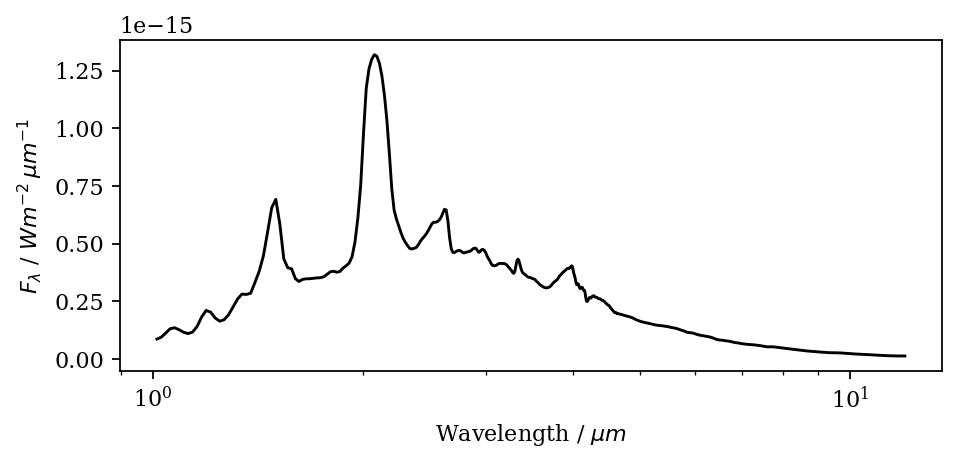

In [32]:
gnostics = 0
trimspec, photspec, tauspec, cfunc0 = test_module.modelspec(
    theta_model, re_params, args_instance, gnostics
)

wave_model, spectrum_model = proc_spec(
    inputspec=trimspec,
    theta=theta_model,
    re_params=re_params,
    args_instance=args_instance,
    do_scales=args_instance.do_scales,
    do_shift=args_instance.do_shift,
    do_conv=args_instance.do_conv,
)

plt.rc("font", family="serif")
fig = plt.figure(dpi=160, figsize=(6, 3))
ax = fig.add_subplot(1, 1, 1)
ax.plot(wave_model, spectrum_model, color="black", lw=1.3)
ax.set_xscale("log")
ax.set_ylabel(r"$F_{\lambda}$ / $Wm^{-2}\,\mu m^{-1}$")
ax.set_xlabel(r"Wavelength / $\mu m$")
fig.tight_layout()
plt.show()


## 5. Forward-model diagnostics


In [33]:
patch_index = 0

gnostics = 1
trimspec_diag, clphotspec, ophotspec, cfunc = test_module.modelspec(
    theta_model, re_params, args_instance, gnostics
)

cfunc = np.reshape(cfunc[patch_index, :, :], (cfunc.shape[1], cfunc.shape[2]))

wavenew = (1e4 / np.asarray(args_instance.inwavenum))[::-1]
press = np.asarray(args_instance.press).reshape(-1,)

fwhm = 0.0026
disp = np.median(np.abs(np.diff(wavenew)))
sigma_pix = (fwhm / 2.355) / disp

if (fwhm <= 0) or (sigma_pix < 0.5):
    gauss = None
else:
    gauss = Gaussian1DKernel(stddev=sigma_pix)

tau1_cl_Press = (convolve(clphotspec[patch_index], gauss, boundary="extend") if gauss else clphotspec[patch_index])[::-1]
tau1_oth_Press = (convolve(ophotspec[patch_index], gauss, boundary="extend") if gauss else ophotspec[patch_index])[::-1]
tau_cloud = tau1_cl_Press
tau_gas = tau1_oth_Press

normfunc = np.zeros_like(cfunc)
tot = np.sum(cfunc, axis=1)
good = np.isfinite(tot) & (tot > 0)
normfunc[good, :] = (cfunc[good, :].T / tot[good]).T

cloud_diag = get_cloud_photospheres(theta_model, re_params, args_instance)

print("cloudmap:\n", args_instance.cloudmap)
for index, label in enumerate(cloud_diag.labels):
    print(f"column {index}: {label}")
print("species array shape (patch, cloud, wavelength):", cloud_diag.species.shape)


cloudmap:
 [[1 1 1]]
column 0: Mg2SiO4.mieff
column 1: SiO.mieff
column 2: Fe.mieff
species array shape (patch, cloud, wavelength): (1, 3, 24850)


## 6. Contribution function and tau=1 lines


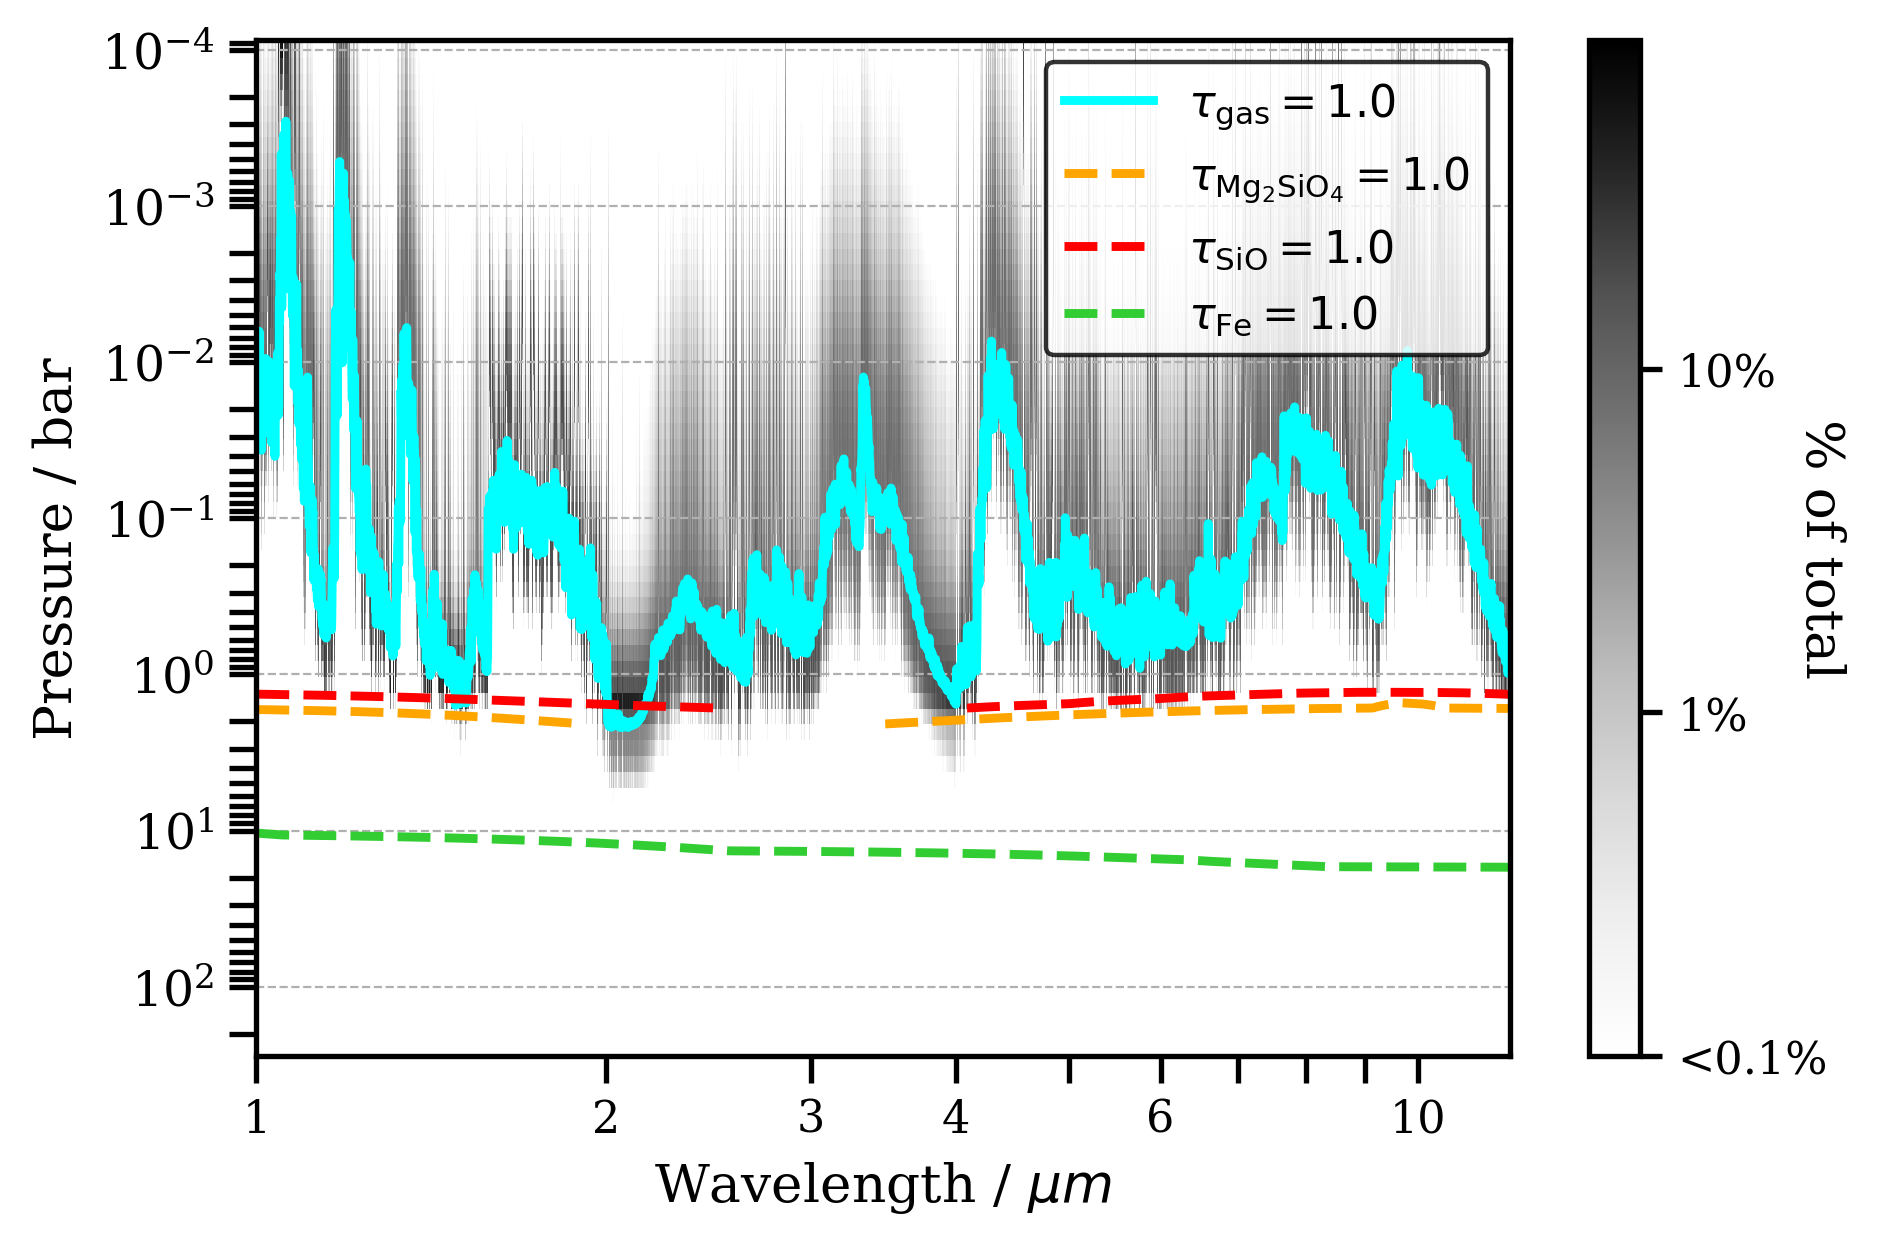

In [34]:
wave = wavenew
pressure = press

plt.rc("font", family="serif")
plt.rc("text", usetex=False)

fig = plt.figure(figsize=(6, 4), dpi=320)
ax = fig.add_subplot(1, 1, 1)

ax.set_yscale("log")
ax.invert_yaxis()
ax.set_xscale("log")

pcm = ax.pcolormesh(
    wave,
    pressure,
    normfunc[::-1, :].T,
    cmap="Greys",
    norm=colors.SymLogNorm(
        linthresh=1e-3,
        linscale=1e-5,
        vmin=0.0,
        vmax=np.nanmax(normfunc),
    ),
)

t_gas, = ax.plot(
    wave,
    tau_gas,
    color="cyan",
    lw=2,
    label=r"$\tau_{\mathrm{gas}} = 1.0$",
)

cloud_colours = ["orange", "red", "limegreen", "dodgerblue", "magenta", "gold"]

handles = [t_gas]
for cloud_index, label in enumerate(cloud_diag.labels):
    if args_instance.cloudmap[patch_index, cloud_index] == 0:
        continue

    lines = plot_tau1_segments(
        ax,
        cloud_diag.wavelength,
        cloud_diag.species[patch_index, cloud_index],
        color=cloud_colours[cloud_index % len(cloud_colours)],
        label=tau_label(label),
        gauss=gauss,
    )

    for line in lines:
        line_label = line.get_label()
        if line_label is not None and line_label != "_nolegend_":
            handles.append(line)

leg = ax.legend(handles=handles, fontsize="medium", loc="upper right", frameon=True)
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(1.0)
for text in leg.get_texts():
    text.set_color("black")

cbar = plt.colorbar(pcm, orientation="vertical", ticks=[1e-3, 1e-2, 1e-1, 1.0])
cbar.ax.set_yticklabels(["<0.1%", "1%", "10%", "100%"])
cbar.set_label("% of total", rotation=270, fontsize=12, color="black")
cbar.ax.tick_params(colors="black", width=1.2, length=5)
for spine in cbar.ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.2)

ax.set_ylabel("Pressure / bar", fontsize=12, color="black")
ax.set_xlabel(r"Wavelength / $\mu m$", fontsize=12, color="black")

ax.tick_params(axis="both", which="both", colors="black", width=1.2, length=6, labelsize=11)
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.2)

ax.grid(linestyle="--", linewidth=0.5, axis="y")

ax.set_xticks([1.0, 2.0, 3.0, 4.0, 6.0, 10.0])
ax.set_xticklabels(["1", "2", "3", "4", "6", "10"], fontsize=10, color="black")


plt.tight_layout()
plt.show()


## 7. Layer optical depth


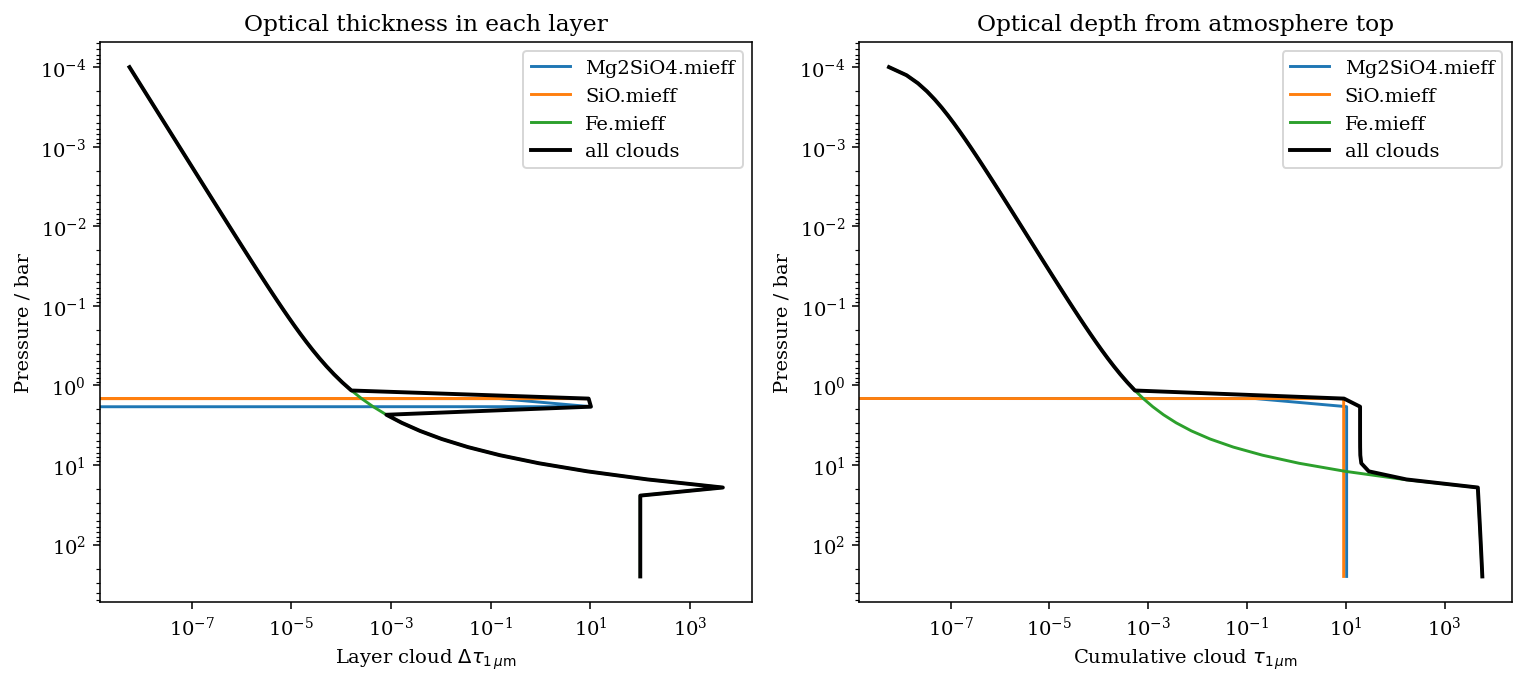

In [35]:
layer_clouds = get_cloud_layer_optical_depth(theta_model, re_params, args_instance)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), dpi=140)
plot_cloud_layer_optical_depth(layer_clouds, patch=patch_index,
                               cumulative=False, ax=axes[0])
plot_cloud_layer_optical_depth(layer_clouds, patch=patch_index,
                               cumulative=True, ax=axes[1])
axes[0].set_title("Optical thickness in each layer")
axes[1].set_title("Optical depth from atmosphere top")
fig.tight_layout()
plt.show()


## 8. Cloud species masses and Mg/Si


In [36]:
cloud_species = get_cloud_species_masses(theta_model, re_params, args_instance)
cloudmass = cloud_species.mass
cloudnumdens = cloud_species.formula_units

column_mass = cloud_species.column_mass[patch_index]
column_formula_units = cloud_species.column_formula_units[patch_index]

print("Cloud order:", list(cloud_species.labels))
for label, mass_col, n_col in zip(cloud_species.labels, column_mass, column_formula_units):
    print(f"{label} column mass [g cm^-2]: {mass_col}")
    print(f"{label} cloud number density [cm^-2]: {n_col}")

element_columns = {}
for n_col, stoich in zip(column_formula_units, cloud_species.stoichiometry):
    for element, count in stoich.items():
        element_columns[element] = element_columns.get(element, 0.0) + count * n_col

MgSi_numdens = element_columns.get("Mg", np.nan) / element_columns.get("Si", np.nan)
print("Element columns [cm^-2]:", element_columns)
print(f"Mg/Si from cloudnumdens = {MgSi_numdens}")


Cloud order: ['Mg2SiO4.mieff', 'SiO.mieff', 'Fe.mieff']
Mg2SiO4.mieff column mass [g cm^-2]: 0.05219946958485017
Mg2SiO4.mieff cloud number density [cm^-2]: 2.2343393413056686e+20
SiO.mieff column mass [g cm^-2]: 0.03259206389241779
SiO.mieff cloud number density [cm^-2]: 4.452222355228105e+20
Fe.mieff column mass [g cm^-2]: 1.1312032621616233
Fe.mieff cloud number density [cm^-2]: 1.219852318543912e+22
Element columns [cm^-2]: {'Mg': 4.468678682611337e+20, 'Si': 6.686561696533774e+20, 'O': 1.338957972045078e+21, 'Fe': 1.219852318543912e+22}
Mg/Si from cloudnumdens = 0.6683074030301465
